<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 1: Implementación de un modelo por Random Forest</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clasificadore basados en **Random Forest** para predecir la **aceptabilidad/seguridad de un automóvil**. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Entrenar dos modelos (con pocos y con muchos árboles) para observar cómo mejora la exactitud, demostrar el proceso de **selección de características** basado en la importancia de variables, y reconstruir el modelo con las variables más relevantes. </li>

</ul>
</div>

**Random Forest** (bosque aleatorio) es un algoritmo de **aprendizaje supervisado** basado en **ensamble** (*ensemble learning*). Tiene dos variantes: una para **clasificación** y otra para **regresión**. Es uno de los algoritmos más flexibles y fáciles de usar.

Construye **múltiples árboles de decisión** sobre distintas muestras de los datos, obtiene la predicción de cada árbol y selecciona la mejor solución mediante **votación**. Además, es un excelente indicador de la **importancia de las variables**.

> Al combinar muchos árboles se forma un "bosque"; de ahí el nombre **Random Forest**. Cuantos **más árboles**, mayor suele ser la exactitud (hasta estabilizarse).

#### Selección de características con Random Forest

El Random Forest permite **ordenar la importancia** de las variables. Durante el entrenamiento, se registra el **error out-of-bag (OOB)** y se promedia sobre el bosque.

Para medir la importancia de la característica *j*, se **permutan** sus valores en los datos y se recalcula el error OOB sobre ese conjunto perturbado. La **importancia** es la diferencia promedio de error OOB antes y después de la permutación, normalizada por su desviación estándar.

Las características que producen valores **grandes** de esta puntuación son más importantes. Con base en ella, conservaremos las más relevantes y descartaremos las menos útiles.

**Planteamiento del problema**

El objetivo es **predecir la aceptabilidad/seguridad de un automóvil** con un clasificador Random Forest en Python y scikit-learn, usando el [**Car Evaluation Data Set**](http://archive.ics.uci.edu/ml/datasets/Car+Evaluation) de la UCI.

El **Car Evaluation Data Set** relaciona la evaluación del automóvil (`class`) con **seis atributos de entrada**:

| Variable | Descripción | Valores |
|---|---|---|
| `buying` | Precio de compra | vhigh, high, med, low |
| `maint` | Costo de mantenimiento | vhigh, high, med, low |
| `doors` | Número de puertas | 2, 3, 4, 5more |
| `persons` | Capacidad de personas | 2, 4, more |
| `lug_boot` | Tamaño de la cajuela | small, med, big |
| `safety` | Seguridad estimada | low, med, high |
| `class` | **Objetivo:** evaluación | unacc, acc, good, vgood |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Cargar el dataset desde archivo local
# El archivo car.data ya está incluido en la carpeta data/car_evaluation
data_path = 'data/car_evaluation/car.data'
df = pd.read_csv(data_path, header=None)

# Alternativa: descarga al vuelo desde la UCI (requiere internet y a veces falla por SSL)
# url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
# df = pd.read_csv(url, header=None)

df.shape

(1728, 7)

## 1.- Análisis exploratorio de datos

In [4]:
# Primeras filas (columnas aún sin nombre)
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [5]:
# Nombrar las columnas según la descripción del dataset
column_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = column_names
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [7]:
# Veamos la información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
# Distribución de frecuencias de cada una de las columnas
for col in column_names:
    print(df[col].value_counts())
    print('-' * 30)

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
------------------------------
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
------------------------------
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
------------------------------
persons
2       576
4       576
more    576
Name: count, dtype: int64
------------------------------
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
------------------------------
safety
low     576
med     576
high    576
Name: count, dtype: int64
------------------------------
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64
------------------------------


### Variable objetivo `class` y valores faltantes
La variable objetivo es **ordinal** (unacc < acc < good < vgood).

In [9]:
# Analizamos la columna class, que es la variable objetivo (target) del dataset
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [10]:
# Analizamos si hay valores nulos en el dataset
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

## 2. Definir variables predictoras y objetivo

In [32]:
X = df.drop(['class'], axis=1)
y = df['class']

In [33]:
X

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med


In [34]:
y

0       unacc
1       unacc
2       unacc
3       unacc
4       unacc
        ...  
1723     good
1724    vgood
1725    unacc
1726     good
1727    vgood
Name: class, Length: 1728, dtype: object

## 3. Dividir en entrenamiento y prueba

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape

((1157, 6), (571, 6))

## 4. Ingeniería de características (codificación)

Todas las variables son **categóricas ordinales**; las convertimos a números con `OrdinalEncoder` de scikit-learn (sin dependencias externas).

In [36]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
X_train = pd.DataFrame(encoder.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(encoder.transform(X_test), columns=X.columns, index=X_test.index)

X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,3.0,3.0,1.0,2.0,1.0,1.0
468,0.0,3.0,1.0,1.0,2.0,1.0
155,3.0,0.0,1.0,2.0,2.0,0.0
1721,1.0,1.0,3.0,2.0,2.0,0.0
1208,2.0,1.0,0.0,2.0,2.0,0.0


## 5. Random Forest con pocos árboles (modelo 1)

Entrena un bosque con **10 árboles** para tener una referencia.


In [37]:
# Instanciamos librerias
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [38]:
# Entrenamiento del modelo Random Forest con 10 arboles
rf_10 = RandomForestClassifier(
    n_estimators=10, max_features='sqrt', oob_score=True,
    random_state=42, n_jobs=-1,
).fit(X_train, y_train)

print('Random Forest 10 -> test accuracy:', round(accuracy_score(y_test, rf_10.predict(X_test)), 4))

Random Forest 10 -> test accuracy: 0.9545


## 6. Random Forest con muchos arboles `n_estimators=100`

Entrena un modelo con **100 árboles** y comenta lo que puedas observar.

In [39]:
# Entrenamiento del modelo Random Forest con 100 arboles
rf_100 = RandomForestClassifier(
    n_estimators=100, max_features='sqrt', oob_score=True,
    random_state=42, n_jobs=-1,
).fit(X_train, y_train)

print('Random Forest 100 -> test accuracy:', round(accuracy_score(y_test, rf_100.predict(X_test)), 4))

Random Forest 100 -> test accuracy: 0.9597


## 7. Importancia de las características

Usa el atributo `feature_importances_` del bosque para ordenar las variables por relevancia.

In [40]:
# Importancia de las caracteristicas
imp = pd.Series(rf_100.feature_importances_, index=X.columns).sort_values()
imp

doors       0.070847
lug_boot    0.089366
maint       0.158177
buying      0.191815
persons     0.219048
safety      0.270748
dtype: float64

## 8. Visualizar la importancia de las características

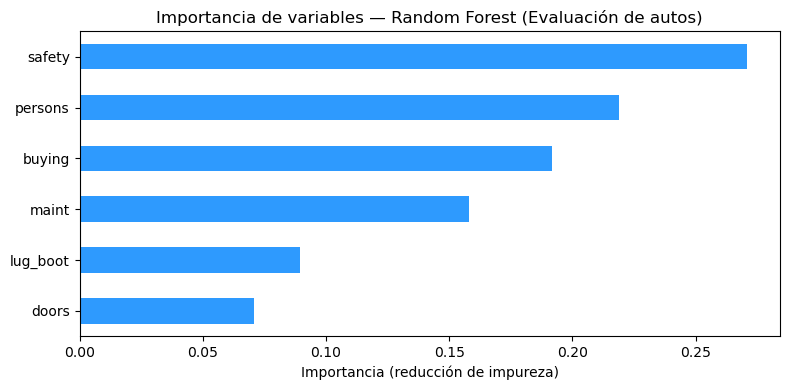

In [41]:
# Visualizamos la importancia de las variables en un gráfico de barras horizontales
plt.figure(figsize=(8, 4))
imp.plot.barh(color='#2E9AFE')
plt.xlabel('Importancia (reducción de impureza)')
plt.title('Importancia de variables — Random Forest (Evaluación de autos)')
plt.tight_layout()
plt.show()

## 9. Reconstruir el modelo con las características seleccionadas

Elimina la variable **menos importante**, reconstruye el modelo y compara la exactitud.

In [42]:
# Nuevo conjunto de variables sin 'doors'
Xx = X.drop(['doors'], axis=1)

In [43]:
# Dividimos el dataset en entrenamiento y prueba
Xx_train, Xx_test, yy_train, yy_test = train_test_split(Xx, y, test_size=0.33, random_state=42)
Xx_train.shape, Xx_test.shape

((1157, 5), (571, 5))

In [44]:
# Codificamos caracteristicas
encoder = OrdinalEncoder()
Xx_train = pd.DataFrame(encoder.fit_transform(Xx_train), columns=Xx.columns, index=Xx_train.index)
Xx_test = pd.DataFrame(encoder.transform(Xx_test), columns=Xx.columns, index=Xx_test.index)

Xx_train.head()

,buying,maint,persons,lug_boot,safety
48,3.0,3.0,2.0,1.0,1.0
468,0.0,3.0,1.0,2.0,1.0
155,3.0,0.0,2.0,2.0,0.0
1721,1.0,1.0,2.0,2.0,0.0
1208,2.0,1.0,2.0,2.0,0.0


In [45]:
# Entrenamiento del modelo Random Forest con 100 arboles sin la columna 'doors'
rfl_100 = RandomForestClassifier(
    n_estimators=100, max_features='sqrt', oob_score=True,
    random_state=42, n_jobs=-1,
).fit(Xx_train, yy_train)

print('Random Forest 100 sin doors -> test accuracy:', round(accuracy_score(yy_test, rfl_100.predict(Xx_test)), 4))

Random Forest 100 sin doors -> test accuracy: 0.9299


## 10. Crea un Reporte de clasificación (Sin la columna doors)

Muestra **precision**, **recall**, **f1-score** y **support** por clase.

Reporte de clasificación (rfl_100, sin doors)
              precision    recall  f1-score   support

         acc       0.89      0.84      0.86       129
        good       0.53      0.80      0.64        20
       unacc       0.98      0.97      0.98       397
       vgood       0.80      0.80      0.80        25

    accuracy                           0.93       571
   macro avg       0.80      0.85      0.82       571
weighted avg       0.94      0.93      0.93       571



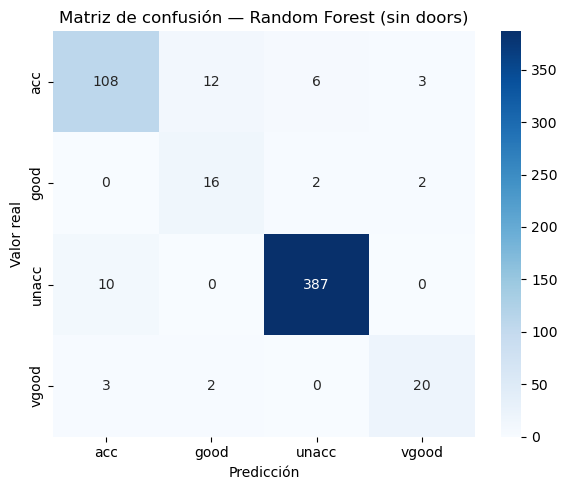

In [46]:
# Reporte de clasificación del modelo final (Random Forest 100 árboles, sin 'doors')
from sklearn.metrics import classification_report, confusion_matrix

# Predicciones sobre el conjunto de prueba
yy_pred = rfl_100.predict(Xx_test)

# Reporte con precision, recall, f1-score y support por clase
print('Reporte de clasificación (rfl_100, sin doors)')
print('=' * 55)
print(classification_report(yy_test, yy_pred))

# Matriz de confusión para visualizar aciertos/errores por clase
labels = sorted(y.unique())
cm = confusion_matrix(yy_test, yy_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión — Random Forest (sin doors)')
plt.tight_layout()
plt.show()

## 10. Crea un Reporte de clasificación (Todas las columnas)

Muestra **precision**, **recall**, **f1-score** y **support** por clase.

Reporte de clasificación (rf_100)
              precision    recall  f1-score   support

         acc       0.93      0.89      0.91       129
        good       0.71      0.85      0.77        20
       unacc       0.98      0.99      0.99       397
       vgood       0.92      0.88      0.90        25

    accuracy                           0.96       571
   macro avg       0.89      0.90      0.89       571
weighted avg       0.96      0.96      0.96       571



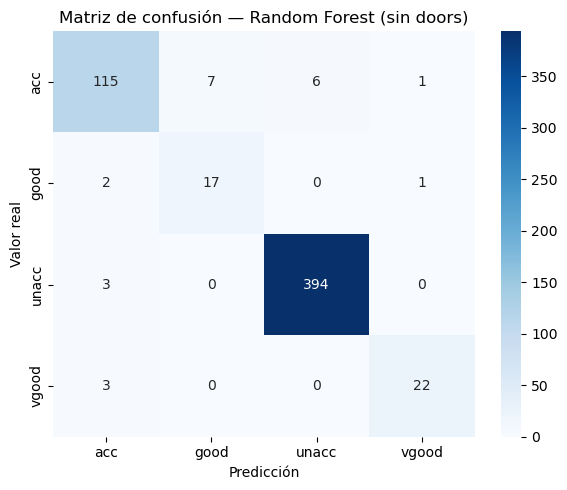

In [ ]:
# Reporte de clasificación del modelo final (Random Forest 100 árboles, con todas las variables)
from sklearn.metrics import classification_report, confusion_matrix

# Predicciones sobre el conjunto de prueba
y_pred = rf_100.predict(X_test)

# Reporte con precision, recall, f1-score y support por clase
print('Reporte de clasificación (rf_100)')
print('=' * 55)
print(classification_report(y_test, y_pred))

# Matriz de confusión para visualizar aciertos/errores por clase
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión — Random Forest (con todas las variables)')
plt.tight_layout()
plt.show()

## 11. Conclusiones en la creación de modelos con 10 y 100 arboles

El accuracy obtenido de los modelos random forest con **10 y 100 arboles** mejoró un poco con los siguientes resultados respectivamente **0.9545** a **0.9597**.

## 12. Conclusiones al eliminar la columna doors

Al reconstruir el modelo (Se probó solo con 100 árboles) y quitar la columna doors la cual era la de menor importancia disminuyo significativamente el accuracy  de **0.9597** a **0.9299** casi 3 puntos porcentuales. Lo que se concluye es que la columna doors aunque es la de menor importancia si ayuda tener mejor accuracy en el modelo.